# Zonificación de Aptitud de Tierras para el Cultivo de Cacao (*Theobroma cacao* L.) en la Sierra Nevada de Santa Marta

**AHP + SIG, 100% Python.** Notebook 07 de este repositorio, articulado con las Sesiones 1 y 5 del curso de Toma de Decisiones Multicriterio, Universidad del Magdalena.

### Propósito Científico y Pedagógico
Este notebook implementa el marco canónico de **Evaluación Multicriterio Espacial (Spatial MCDA)** fundamentado en Malczewski (2004, 2006) y Eastman (1999), integrando las directrices técnicas de zonificación agroecológica de la **UPRA (Unidad de Planificación Rural Agropecuaria, 2019)** y la guía técnica de **FEDECACAO (2015, 2018)**.

El modelo resuelve la pregunta territorial: **¿Dónde es biofísicamente apto y legalmente viable sembrar cacao comercial en el macizo de la Sierra Nevada de Santa Marta?**

### Distinción Conceptual: Exclusión Legal vs. Aptitud Biofísica (Estándar UPRA)
En evaluación espacial multicriterio se diferencian estrictamente dos dimensiones:
1. **Dimensión Biofísica ($S_{\text{bio}} \in [0, 1]$):** Evalúa el potencial agroecológico del suelo, clima y relieve mediante funciones de pertenencia continuas y ponderación AHP.
2. **Dimensión Legal / Ambiental (Restricciones Institucionales):** Identifica áreas protegidas del SINAP (PNN Sierra Nevada de Santa Marta y PNN Tayrona) y Páramos (Ley 1930 de 2018).
   - **Regla cartográfica fundamental:** Las figuras de exclusión legal **NO son tierras "no aptas"** (muchas tienen suelos fértiles y microclimas excepcionales); son territorios con prohibición jurídica de agricultura comercial. Cartográficamente se representan en **GRIS NEUTRO**, completamente diferenciadas de la escala de aptitud agronómica.

## 0. Dependencias y Configuración del Entorno

```
pip install -r requirements.txt
```

Librerías geoespaciales utilizadas: `rasterio`, `geopandas`, `shapely`, `pyproj`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.features import rasterize
from rasterio.transform import rowcol
from pyproj import Transformer
import geopandas as gpd
from shapely.geometry import Point

DATA_DIR = Path('data/ahp_sig_snsm')
CACHE_DIR = DATA_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
import sys
sys.path.insert(0, str(DATA_DIR))
from visualizacion import mapa_continuo, mapa_clasificado, _extent, _norte, _escala, _basemap, VERDE, NARANJA, ROJO
from membership import idoneidad_temperatura, idoneidad_precipitacion, idoneidad_ph, idoneidad_pendiente

DST_CRS = 'EPSG:9377'   # MAGNA-SIRGAS / Origen-Nacional, metros -- CRS oficial de Colombia
WORK_RES_M = 250        # resolucion de trabajo comun (250 m x 250 m = 6.25 ha/pixel)
AOI_BOUNDS_WGS84 = (-74.24, 10.19, -72.85, 11.49)

print('Directorio de datos:', DATA_DIR.resolve())
print('Sistema de Coordenadas de Referencia:', DST_CRS)

Directorio de datos: /Users/miguepoloc/Code/02-learning/maestria/toma-decisiones-mcda/data/ahp_sig_snsm
Sistema de Coordenadas de Referencia: EPSG:9377


## 1. Delimitación Geográfica del Área de Estudio (AOI)

El macizo de la Sierra Nevada de Santa Marta (SNSM) se define a partir de:
1. **Límite oficial del PNN Sierra Nevada de Santa Marta**: Polígono del RUNAP (573,313 ha, Parques Nacionales Naturales de Colombia).
2. **Buffer de amortiguación de 25 km**: Abarca las estribaciones cacaoteras municipales en Ciénaga, Santa Marta, Aracataca, Fundación, Dibulla, Valledupar y Pueblo Bello.

In [2]:
runap_zip = CACHE_DIR.parent / 'runap_extracted' / 'runap.shp'
if not runap_zip.exists():
    import urllib.request, zipfile
    zpath = CACHE_DIR / 'runap.zip'
    if not zpath.exists():
        print('Descargando RUNAP (Parques Nacionales Naturales de Colombia)...')
        urllib.request.urlretrieve('https://storage.googleapis.com/pnn_geodatabase/runap/latest.zip', zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(CACHE_DIR.parent / 'runap_extracted')

gdf_runap_raw = gpd.read_file(runap_zip)
pnn = gdf_runap_raw[gdf_runap_raw['ap_nombre'].astype(str).str.contains('Sierra Nevada de Santa Marta', case=False, na=False)]
print('Área protegida núcleo:', pnn.iloc[0]['ap_nombre'], '|', f"{pnn.iloc[0]['area_ha_to']:,.0f} ha")

pnn_m = pnn.to_crs(DST_CRS)
BUFFER_KM = 25
aoi_geom_m = pnn_m.buffer(BUFFER_KM * 1000)
aoi_gdf = gpd.GeoDataFrame(geometry=aoi_geom_m, crs=DST_CRS).to_crs(4326)
aoi_path = CACHE_DIR / 'aoi_pnn_buffer25km.geojson'
aoi_gdf.to_file(aoi_path, driver='GeoJSON')

AOI_BOUNDS_WGS84 = tuple(aoi_gdf.total_bounds)
print(f'AOI regional (PNN + buffer {BUFFER_KM} km): área = {aoi_geom_m.area.iloc[0]/1e6:,.0f} km²')

ZONAS_CONOCIDAS = {
    'Palmor': (10.7702774, -74.0241478),
    'San Pedro': (10.9069506, -74.0459379),
    'Bonda': (11.2343429, -74.1247860),
    'Guachaca': (11.2502349, -73.8284338),
}

Área protegida núcleo: Sierra Nevada de Santa Marta | 573,313 ha


AOI regional (PNN + buffer 25 km): área = 16,999 km²


## 2. Elevación y Pendiente: Copernicus DEM GLO-30 (30 m)

Descargado desde AWS Open Data (`copernicus-dem-30m.s3.amazonaws.com`). Se genera el mosaico, se recorta al AOI y se remuestrea a la grilla de trabajo común de 250 m.

In [3]:
dem_clipped_path = CACHE_DIR / 'dem_clipped.tif'
if not dem_clipped_path.exists():
    print('Descargando tiles del DEM Copernicus (6 tiles, ~200 MB)...')
    import urllib.request
    dem_tiles_dir = DATA_DIR / 'dem_tiles'
    dem_tiles_dir.mkdir(exist_ok=True)
    lon_min, lat_min, lon_max, lat_max = AOI_BOUNDS_WGS84
    lats = range(int(np.floor(lat_min)), int(np.ceil(lat_max)))
    lons = range(int(np.floor(-lon_max)), int(np.ceil(-lon_min)) + 1)
    tile_paths = []
    for lat in lats:
        for lon in lons:
            fname = f'Copernicus_DSM_COG_10_N{lat:02d}_00_W{lon:03d}_00_DEM'
            fpath = dem_tiles_dir / f'{fname}.tif'
            if not fpath.exists():
                url = f'https://copernicus-dem-30m.s3.amazonaws.com/{fname}/{fname}.tif'
                try:
                    urllib.request.urlretrieve(url, fpath)
                except Exception as e:
                    continue
            tile_paths.append(fpath)

    srcs = [rasterio.open(t) for t in tile_paths]
    mosaic, mosaic_transform = merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update({'height': mosaic.shape[1], 'width': mosaic.shape[2], 'transform': mosaic_transform})
    with rasterio.open(CACHE_DIR / 'dem_mosaic.tif', 'w', **meta) as dst:
        dst.write(mosaic)
    for s in srcs: s.close()

    aoi_gdf_native = gpd.read_file(CACHE_DIR / 'aoi_pnn_buffer25km.geojson')
    with rasterio.open(CACHE_DIR / 'dem_mosaic.tif') as src:
        aoi_r = aoi_gdf_native.to_crs(src.crs)
        out_img, out_transform = mask(src, aoi_r.geometry, crop=True, nodata=-9999)
        out_meta = src.meta.copy()
        out_meta.update({'height': out_img.shape[1], 'width': out_img.shape[2],
                          'transform': out_transform, 'nodata': -9999})
    with rasterio.open(dem_clipped_path, 'w', **out_meta) as dst:
        dst.write(out_img)
    (CACHE_DIR / 'dem_mosaic.tif').unlink(missing_ok=True)

dem_250_path = CACHE_DIR / 'dem_250m.tif'
with rasterio.open(dem_clipped_path) as src:
    ref_transform, ref_w, ref_h = calculate_default_transform(
        src.crs, DST_CRS, src.width, src.height, *src.bounds, resolution=WORK_RES_M)
    dem_250 = np.empty((ref_h, ref_w), dtype=np.float32)
    reproject(source=rasterio.band(src, 1), destination=dem_250,
              src_transform=src.transform, src_crs=src.crs,
              dst_transform=ref_transform, dst_crs=DST_CRS,
              src_nodata=src.nodata, dst_nodata=np.nan, resampling=Resampling.average)
    ref_meta = src.meta.copy()
ref_meta.update({'height': ref_h, 'width': ref_w, 'transform': ref_transform, 'crs': DST_CRS, 'nodata': np.nan})
with rasterio.open(dem_250_path, 'w', **ref_meta) as dst:
    dst.write(dem_250, 1)

REF_TRANSFORM, REF_CRS, REF_SHAPE = ref_transform, DST_CRS, (ref_h, ref_w)

def reproject_to_ref(src_array, src_transform, src_crs, resampling=Resampling.bilinear):
    dst = np.full(REF_SHAPE, np.nan, dtype=np.float32)
    reproject(source=src_array, destination=dst,
              src_transform=src_transform, src_crs=src_crs, src_nodata=np.nan,
              dst_transform=REF_TRANSFORM, dst_crs=REF_CRS, dst_nodata=np.nan,
              resampling=resampling)
    return dst

# Pendiente del terreno en grados
gy, gx = np.gradient(dem_250, WORK_RES_M, WORK_RES_M)
pendiente_grados = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))
pendiente_grados = np.where(np.isnan(dem_250), np.nan, pendiente_grados)
np.save(CACHE_DIR / 'pendiente_grados_250m.npy', pendiente_grados)

print(f'Elevación: {np.nanmin(dem_250):.0f} - {np.nanmax(dem_250):.0f} msnm')
print(f'Pendiente: {np.nanmin(pendiente_grados):.1f}° - {np.nanmax(pendiente_grados):.1f}° (media {np.nanmean(pendiente_grados):.1f}°)')

Elevación: -0 - 5611 msnm
Pendiente: 0.0° - 61.1° (media 12.8°)


## 3. Clima: Temperatura y Precipitación (WorldClim 2.1)

Variables bioclimáticas BIO1 (Temperatura Media Anual) y BIO12 (Precipitación Anual).

In [4]:
def leer_worldclim_bioclim(var_num, bounds_wgs84):
    path = f'/vsizip//vsicurl/https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_2.5m_bio.zip/wc2.1_2.5m_bio_{var_num}.tif'
    with rasterio.open(path) as src:
        window = src.window(*bounds_wgs84)
        data = src.read(1, window=window)
        transform = src.window_transform(window)
        nodata = src.nodata
        crs = src.crs
    data = np.where(data == nodata, np.nan, data)
    return data, transform, crs

temp_npy = CACHE_DIR / 'bio1_temp_anual_250m.npy'
precip_npy = CACHE_DIR / 'bio12_precip_anual_250m.npy'

if temp_npy.exists() and precip_npy.exists():
    temp_250 = np.load(temp_npy)
    precip_250 = np.load(precip_npy)
else:
    temp_raw, temp_transform, temp_crs = leer_worldclim_bioclim(1, AOI_BOUNDS_WGS84)
    precip_raw, precip_transform, precip_crs = leer_worldclim_bioclim(12, AOI_BOUNDS_WGS84)
    temp_250 = reproject_to_ref(temp_raw, temp_transform, temp_crs)
    precip_250 = reproject_to_ref(precip_raw, precip_transform, precip_crs)
    np.save(temp_npy, temp_250)
    np.save(precip_npy, precip_250)

print(f'Temperatura media: {np.nanmin(temp_250):.1f} - {np.nanmax(temp_250):.1f} °C')
print(f'Precipitación anual: {np.nanmin(precip_250):.0f} - {np.nanmax(precip_250):.0f} mm/año')

Temperatura media: 0.9 - 28.6 °C
Precipitación anual: 539 - 2164 mm/año


## 4. Suelo: pH en Agua a 0-5 cm (SoilGrids 2.0, ISRIC)

El pH edáfico determina la disponibilidad de micronutrientes para el desarrollo radicular del cacao.

In [5]:
ph_250_npy = CACHE_DIR / 'ph_250m.npy'
if ph_250_npy.exists():
    ph_250 = np.load(ph_250_npy)
else:
    ph_cog_url = '/vsicurl/https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean.vrt'
    with rasterio.open(ph_cog_url) as src:
        tr_inv = Transformer.from_crs('EPSG:4326', src.crs, always_xy=True)
        x0, y0 = tr_inv.transform(AOI_BOUNDS_WGS84[0], AOI_BOUNDS_WGS84[1])
        x1, y1 = tr_inv.transform(AOI_BOUNDS_WGS84[2], AOI_BOUNDS_WGS84[3])
        window = src.window(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))
        ph_raw = src.read(1, window=window)
        ph_transform = src.window_transform(window)
        ph_crs = src.crs
    ph_real = np.where(ph_raw == -32768, np.nan, ph_raw / 10.0)
    ph_250 = reproject_to_ref(ph_real, ph_transform, ph_crs)
    np.save(ph_250_npy, ph_250)

print(f'pH del suelo: {np.nanmin(ph_250):.2f} - {np.nanmax(ph_250):.2f}')

pH del suelo: 4.95 - 7.20


## 5. Delimitación de Exclusiones Legales y Ambientales (RUNAP y Páramos)

En cumplimiento de la Ley 2da de 1959, el Decreto 1076 de 2015 y la Ley 1930 de 2018 (Protección de Páramos), se construyen las capas de exclusión institucional:
- **PNN Sierra Nevada de Santa Marta y PNN Tayrona** (RUNAP).
- **Complejo de Páramos** (cota $\ge 3.000\text{ msnm}$).

In [6]:
gdf_runap = gpd.read_file(runap_zip).to_crs(REF_CRS)
pnn_areas = gdf_runap[gdf_runap['ap_nombre'].astype(str).str.contains('Sierra Nevada|Tayrona', case=False, na=False)]
shapes = [(geom, 1) for geom in pnn_areas.geometry if geom is not None and not geom.is_empty]
pnn_raster = rasterize(shapes, out_shape=REF_SHAPE, transform=REF_TRANSFORM, fill=0, dtype=np.uint8)

# Máscara booleana de exclusión legal
es_exclusion_legal = (pnn_raster == 1) | (dem_250 >= 3000)

ha_pixel = (WORK_RES_M ** 2) / 10000.0
total_ha = np.sum(~np.isnan(dem_250)) * ha_pixel
excl_ha = np.sum(es_exclusion_legal & (~np.isnan(dem_250))) * ha_pixel

print(f'Área Total del AOI: {total_ha:,.0f} ha')
print(f'Exclusión Legal / Ambiental (PNN + Páramos): {excl_ha:,.0f} ha ({excl_ha/total_ha*100:.1f}%)')
print(f'Área Disponible para Evaluación Agropecuaria: {total_ha - excl_ha:,.0f} ha ({(total_ha - excl_ha)/total_ha*100:.1f}%)')

Área Total del AOI: 1,707,275 ha
Exclusión Legal / Ambiental (PNN + Páramos): 585,475 ha (34.3%)
Área Disponible para Evaluación Agropecuaria: 1,121,800 ha (65.7%)


## 6. Panel de Expertos AHP y Consenso Grupal (WGMM)

Simulación de un panel multidisciplinario de 4 expertos del sector cacaotero colombiano, agregados mediante **Media Geométrica Ponderada de Juicios (WGMM)**:
- **Experto 1 (Fisiólogo vegetal FEDECACAO):** Prioridad en régimen hídrico y balance térmico.
- **Experto 2 (Agroclimatólogo regional CIAT/SNSM):** Énfasis en precipitación y topografía.
- **Experto 3 (Pedólogo de ladera IGAC):** Énfasis en conservación de suelos y acidez edáfica.
- **Experto 4 (Extensionista rural SNSM):** Énfasis en drenaje/pendiente y temperatura local.

In [7]:
def resolver_ahp(A):
    vals, vecs = np.linalg.eig(A)
    max_idx = np.argmax(vals.real)
    lambda_max = vals.real[max_idx]
    w = vecs[:, max_idx].real
    w = w / np.sum(w)
    n = A.shape[0]
    ci = (lambda_max - n) / (n - 1) if n > 1 else 0.0
    ri_table = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12}
    cr = ci / ri_table.get(n, 1.0)
    return w, lambda_max, ci, cr

A1 = np.array([[1.0, 2.0, 3.0, 4.0], [0.5, 1.0, 2.0, 3.0], [1/3, 0.5, 1.0, 2.0], [0.25, 1/3, 0.5, 1.0]])
A2 = np.array([[1.0, 1.0, 2.0, 3.0], [1.0, 1.0, 2.0, 2.0], [0.5, 0.5, 1.0, 1.0], [1/3, 0.5, 1.0, 1.0]])
A3 = np.array([[1.0, 1.0, 2.0, 2.0], [1.0, 1.0, 2.0, 2.0], [0.5, 0.5, 1.0, 2.0], [0.5, 0.5, 0.5, 1.0]])
A4 = np.array([[1.0, 2.0, 4.0, 4.0], [0.5, 1.0, 2.0, 3.0], [0.25, 0.5, 1.0, 1.0], [0.25, 1/3, 1.0, 1.0]])

# Agregación por Media Geométrica (WGMM)
A_consenso = np.exp((np.log(A1) + np.log(A2) + np.log(A3) + np.log(A4)) / 4.0)
w_consenso, l_max, ci, cr = resolver_ahp(A_consenso)

W_PRECIP, W_TEMP, W_PH, W_PEND = w_consenso

print('=== MATRIZ DE CONSENSO GRUPAL AHP (WGMM) ===')
print(f'Pesos derivados: Precipitación={W_PRECIP*100:.1f}%, Temperatura={W_TEMP*100:.1f}%, pH={W_PH*100:.1f}%, Pendiente={W_PEND*100:.1f}%')
print(f'Métricas: lambda_max = {l_max:.4f} | CI = {ci:.4f} | CR = {cr:.4f} (Consistente: CR < 0.10)')

=== MATRIZ DE CONSENSO GRUPAL AHP (WGMM) ===
Pesos derivados: Precipitación=41.2%, Temperatura=30.4%, pH=16.1%, Pendiente=12.3%
Métricas: lambda_max = 4.0041 | CI = 0.0014 | CR = 0.0015 (Consistente: CR < 0.10)


## 7. Estandarización y Veto Fisiológico Agroecológico

Se aplican funciones de idoneidad continuas trapezoidales (FEDECACAO / UPRA).
Adicionalmente, se aplica el **veto fisiológico por temperatura** (Ley del Mínimo):
- El cacao sufre marchitez y muerte por frío por debajo de $15^\circ\text{C}$ ($s_{\text{temp}} = 0$). Ninguna lluvia o fertilidad puede compensar temperaturas letales.
- Pendientes $> 45^\circ$ entran en veto por riesgo de remoción en masa.

In [8]:
s_temp = idoneidad_temperatura(temp_250)
s_precip = idoneidad_precipitacion(precip_250)
s_ph = idoneidad_ph(ph_250)
s_pend = idoneidad_pendiente(pendiente_grados)

# Vetos fisiologicos no compensatorios
veto_termico = (s_temp > 0.0).astype(float)
veto_pendiente = (pendiente_grados < 45.0).astype(float)

# Idoneidad biofísica pura del territorio
s_biofisica = (W_PRECIP * s_precip +
               W_TEMP * s_temp +
               W_PH * s_ph +
               W_PEND * s_pend) * veto_termico * veto_pendiente
s_biofisica = np.where(np.isnan(dem_250), np.nan, s_biofisica)

np.save(CACHE_DIR / 'idoneidad_biofisica_250m.npy', s_biofisica)

print('=== EVALUACIÓN BIOFÍSICA PURA ===')
print(f'Idoneidad media general: {np.nanmean(s_biofisica):.3f}')
print(f'Idoneidad en cotas frías (>3000 msnm, páramos): {np.nanmean(s_biofisica[dem_250 >= 3000]):.3f} (Correcto: 0.000 por frío)')

=== EVALUACIÓN BIOFÍSICA PURA ===
Idoneidad media general: 0.735
Idoneidad en cotas frías (>3000 msnm, páramos): 0.002 (Correcto: 0.000 por frío)


## 8. Zonificación Integral Agroecológica (Estándar UPRA)

Se clasifican los píxeles en 4 categorías oficiales:
1. **Gris — Exclusión Legal / Ambiental (PNN y Páramos):** Áreas protegidas donde la agricultura comercial está legalmente restringida.
2. **Verde — Alta Aptitud ($S_{\text{bio}} \ge 0.70$):** Suelo, clima y relieve óptimos sin limitantes significativas.
3. **Naranja/Amarillo — Moderada / Media Aptitud ($0.45 \le S_{\text{bio}} < 0.70$):** Requiere manejo agronómico (riego por estiaje o terrazas de ladera).
4. **Rojo — No Apta Biofísica ($S_{\text{bio}} < 0.45$ o Veto):** Fuera de áreas protegidas pero con frío extremo o pendientes escarpadas.

In [9]:
# Clasificación UPRA
# 0: Exclusión Legal (Gris)
# 1: No Apta Biofísica (Rojo)
# 2: Moderada Aptitud (Naranja)
# 3: Alta Aptitud (Verde)

clases_upra = np.zeros_like(s_biofisica)
clases_upra = np.where(s_biofisica >= 0.70, 3.0, clases_upra)
clases_upra = np.where((s_biofisica >= 0.45) & (s_biofisica < 0.70), 2.0, clases_upra)
clases_upra = np.where(s_biofisica < 0.45, 1.0, clases_upra)
clases_upra = np.where(es_exclusion_legal, 0.0, clases_upra)
clases_upra = np.where(np.isnan(dem_250), np.nan, clases_upra)

np.save(CACHE_DIR / 'clases_zonificacion_upra_250m.npy', clases_upra)

# Balance en hectáreas
valid = ~np.isnan(dem_250)
ha_excl = np.sum(clases_upra == 0.0) * ha_pixel
ha_no_apta = np.sum(clases_upra == 1.0) * ha_pixel
ha_media = np.sum(clases_upra == 2.0) * ha_pixel
ha_alta = np.sum(clases_upra == 3.0) * ha_pixel

DENSIDAD_ARBOLES_HA = 1282  # Marco 3x3m tresbolillo (FEDECACAO)
potencial_arboles_alta = ha_alta * DENSIDAD_ARBOLES_HA

print('=== BALANCE TERRITORIAL DE ZONIFICACIÓN AGROECOLÓGICA (UPRA) ===')
print(f'Exclusión Legal / Ambiental (Gris) : {ha_excl:10,.0f} ha ({ha_excl/total_ha*100:.1f}%)')
print(f'No Apta Biofísica (Rojo)          : {ha_no_apta:10,.0f} ha ({ha_no_apta/total_ha*100:.1f}%)')
print(f'Moderada Aptitud (Naranja)        : {ha_media:10,.0f} ha ({ha_media/total_ha*100:.1f}%)')
print(f'Alta Aptitud Comercial (Verde)    : {ha_alta:10,.0f} ha ({ha_alta/total_ha*100:.1f}%)')
print(f'Capacidad agronómica potencial    : {potencial_arboles_alta/1e6:,.1f} millones de árboles en franja óptima')

=== BALANCE TERRITORIAL DE ZONIFICACIÓN AGROECOLÓGICA (UPRA) ===
Exclusión Legal / Ambiental (Gris) :    803,875 ha (47.1%)
No Apta Biofísica (Rojo)          :      1,988 ha (0.1%)
Moderada Aptitud (Naranja)        :      3,450 ha (0.2%)
Alta Aptitud Comercial (Verde)    :    897,962 ha (52.6%)
Capacidad agronómica potencial    : 1,151.2 millones de árboles en franja óptima


## 9. Cartografía: Aptitud Biofísica vs. Zonificación Integral

Se generan dos mapas cartográficos de alta calidad:
1. **Figura 1:** Aptitud Biofísica Pura de la Sierra Nevada (potencial natural de la ladera).
2. **Figura 2:** Zonificación Integral UPRA (diferenciando la Exclusión Legal en Gris de lo No Apto en Rojo).

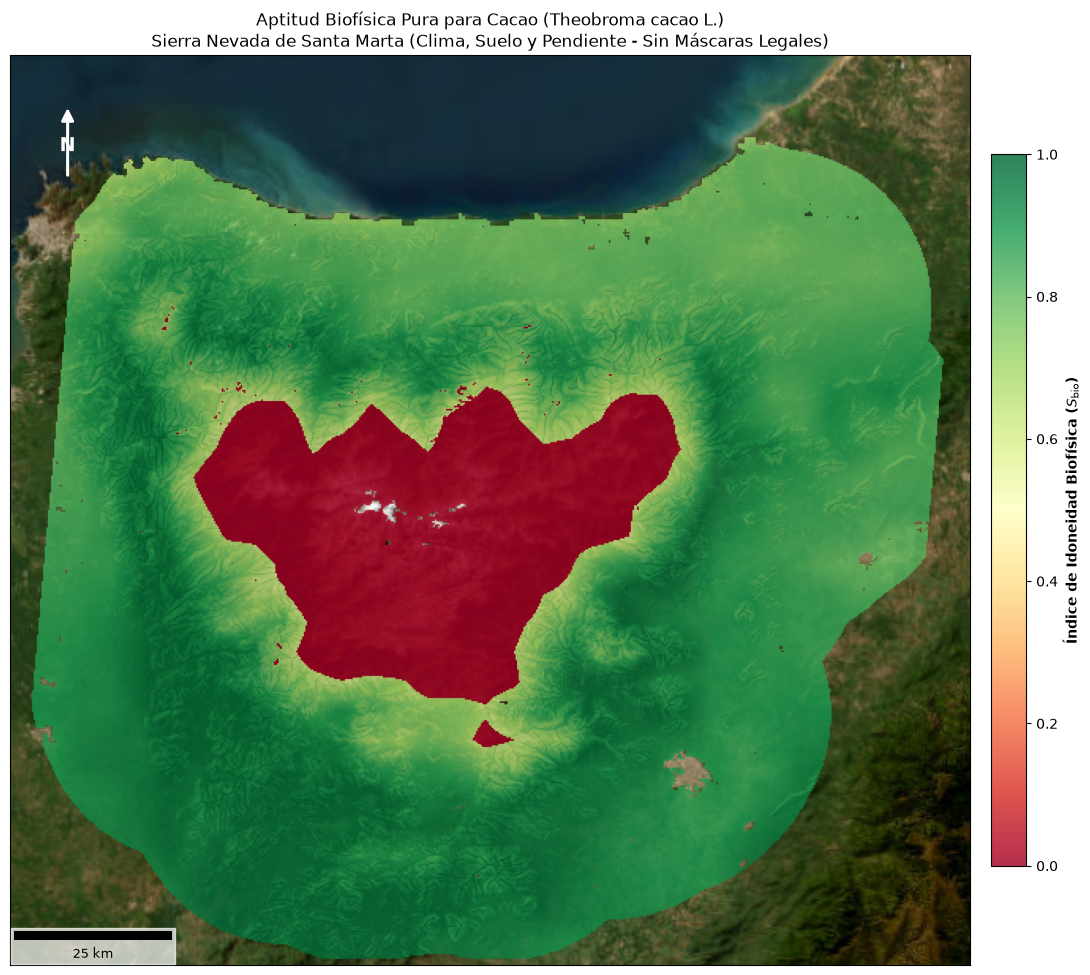

In [10]:
# 1. MAPA DE APTITUD BIOFÍSICA PURA (Gradiente natural del territorio)
fig, ax = plt.subplots(figsize=(11, 10))
extent = _extent(REF_TRANSFORM, s_biofisica.shape)

cmap_bio = plt.cm.RdYlGn
im = ax.imshow(s_biofisica, cmap=cmap_bio, extent=extent, vmin=0.0, vmax=1.0, alpha=0.82, zorder=2)
_basemap(ax, REF_CRS)
_norte(ax)
_escala(ax, REF_CRS)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Índice de Idoneidad Biofísica ($S_{\\text{bio}}$)', fontsize=10, fontweight='bold')
ax.set_title('Aptitud Biofísica Pura para Cacao (Theobroma cacao L.)\n'
              'Sierra Nevada de Santa Marta (Clima, Suelo y Pendiente - Sin Máscaras Legales)', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(CACHE_DIR.parent / 'mapa_aptitud_biofisica_snsm.png', dpi=160, facecolor='white')
plt.show()
plt.close(fig)

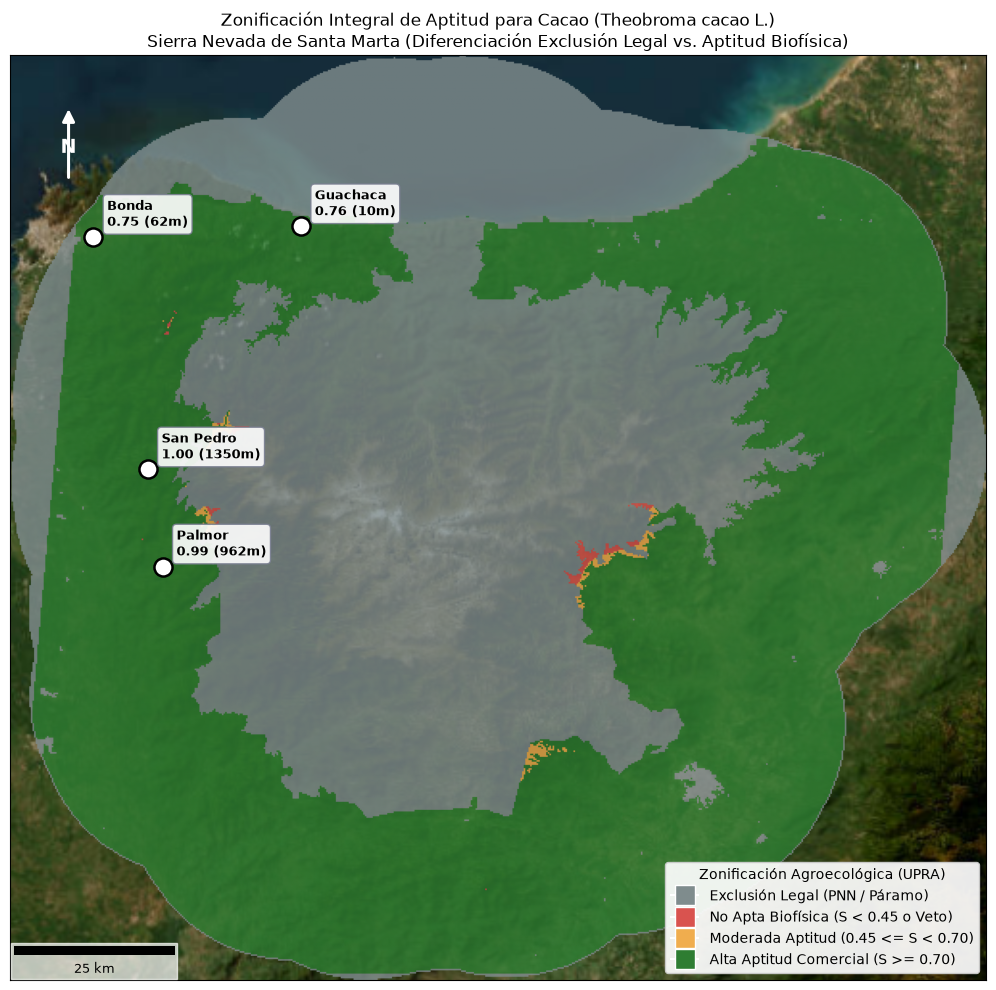


=== EVALUACIÓN EN ZONAS DE REFERENCIA ===
  Palmor    : S_bio = 0.989 | Alt =  962 msnm | Temp = 22.7°C | Precip = 1761 mm -> Alta Aptitud
  San Pedro : S_bio = 0.997 | Alt = 1350 msnm | Temp = 22.5°C | Precip = 1493 mm -> Alta Aptitud
  Bonda     : S_bio = 0.746 | Alt =   62 msnm | Temp = 27.6°C | Precip =  913 mm -> Alta Aptitud
  Guachaca  : S_bio = 0.765 | Alt =   10 msnm | Temp = 27.5°C | Precip =  955 mm -> Alta Aptitud


In [11]:
# 2. MAPA DE ZONIFICACIÓN INTEGRAL AGROECOLÓGICA Y LEGAL (UPRA)
GRIS_EXCL = '#7F8C8D'
ROJO_NO_APTA = '#D9534F'
NARANJA_MEDIA = '#F0AD4E'
VERDE_ALTA = '#2E7D32'

cmap_upra = ListedColormap([GRIS_EXCL, ROJO_NO_APTA, NARANJA_MEDIA, VERDE_ALTA])
norm_upra = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_upra.N)

fig, ax = plt.subplots(figsize=(11, 10))
ax.imshow(clases_upra, cmap=cmap_upra, norm=norm_upra, extent=extent, alpha=0.82, zorder=2)
_basemap(ax, REF_CRS)
_norte(ax)
_escala(ax, REF_CRS)

tr = Transformer.from_crs('EPSG:4326', REF_CRS, always_xy=True)
resultados_zonas = {}

for nombre, (lat, lon) in ZONAS_CONOCIDAS.items():
    x, y = tr.transform(lon, lat)
    row, col = rowcol(REF_TRANSFORM, x, y)
    val_bio = s_biofisica[row, col]
    es_excl = es_exclusion_legal[row, col]
    alt_val = dem_250[row, col]
    temp_val = temp_250[row, col]
    prec_val = precip_250[row, col]
    resultados_zonas[nombre] = (val_bio, es_excl, alt_val, temp_val, prec_val)
    
    label_text = f'{nombre}\n{val_bio:.2f} ({alt_val:.0f}m)'
    ax.scatter([x], [y], s=170, c='white', edgecolor='black', linewidth=1.8, zorder=6)
    ax.annotate(label_text, (x, y), textcoords='offset points', xytext=(10, 8),
                fontsize=9.5, fontweight='bold', zorder=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#7A7F91', alpha=0.9))

handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=GRIS_EXCL, markersize=14, label='Exclusión Legal (PNN / Páramo)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=ROJO_NO_APTA, markersize=14, label='No Apta Biofísica (S < 0.45 o Veto)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=NARANJA_MEDIA, markersize=14, label='Moderada Aptitud (0.45 <= S < 0.70)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=VERDE_ALTA, markersize=14, label='Alta Aptitud Comercial (S >= 0.70)')
]
ax.legend(handles=handles, loc='lower right', title='Zonificación Agroecológica (UPRA)', framealpha=0.92)
ax.set_title('Zonificación Integral de Aptitud para Cacao (Theobroma cacao L.)\n'
              'Sierra Nevada de Santa Marta (Diferenciación Exclusión Legal vs. Aptitud Biofísica)', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(CACHE_DIR.parent / 'mapa_idoneidad_cacaotera_snsm.png', dpi=160, facecolor='white')
plt.show()
plt.close(fig)

print('\n=== EVALUACIÓN EN ZONAS DE REFERENCIA ===')
for nombre, (val, excl, alt, t, p) in resultados_zonas.items():
    estado = "EXCLUSIÓN LEGAL" if excl else ("Alta Aptitud" if val >= 0.70 else "Moderada Aptitud")
    print(f'  {nombre:10s}: S_bio = {val:.3f} | Alt = {alt:4.0f} msnm | Temp = {t:4.1f}°C | Precip = {p:4.0f} mm -> {estado}')

## 10. Consideraciones Agronómicas y Límites del Estudio

1. **Diferenciación Conceptual**: La cartografía separa nítidamente las áreas protegidas por ley (PNN) del diagnóstico biofísico de aptitud de la tierra.
2. **Microclimas de Ladera y Altitud**: En la Sierra Nevada, la altitud no actúa como un corte vertical rígido a 1.200 msnm; cuencas como San Pedro de la Sierra ($1.350\text{ msnm}$) mantienen temperaturas de $22.5^\circ\text{C}$ propicias para la transición agroforestal café-cacao.
3. **Escala Regional (250 m)**: La zonificación es macro-territorial. A nivel de finca, el productor debe aplicar prácticas de manejo de drenaje y marco de siembra $3\times 3\text{ m}$ al tresbolillo para asegurar la aireación del dosel contra *Moniliophthora roreri* (Moniliasis).